In [1]:
import pandas as pd

# Read the CSV file
df = pd.read_csv("/bsuhome/amirhosseinmonta/scratch/watersofthack/USGS_gage_data/usgs_gauge_height_streamflow_long_filled.csv")

# Display the first five rows
print(df.head())

# Show unique values in each column
for column in df.columns:
    print(f"\nColumn: {column}")
    print(df[column].unique())

                    datetime  site_id                  site_name  \
0  2010-01-01 06:00:00+00:00  8193000  Nueces Rv nr Asherton, TX   
1  2010-01-01 06:15:00+00:00  8193000  Nueces Rv nr Asherton, TX   
2  2010-01-01 06:30:00+00:00  8193000  Nueces Rv nr Asherton, TX   
3  2010-01-01 06:45:00+00:00  8193000  Nueces Rv nr Asherton, TX   
4  2010-01-01 07:00:00+00:00  8193000  Nueces Rv nr Asherton, TX   

          river site_category  reach_id   latitude  longitude  \
0  Nueces River        Stream  10893541  28.500263 -99.681993   
1  Nueces River        Stream  10893541  28.500263 -99.681993   
2  Nueces River        Stream  10893541  28.500263 -99.681993   
3  Nueces River        Stream  10893541  28.500263 -99.681993   
4  Nueces River        Stream  10893541  28.500263 -99.681993   

   drainage_area_sqmi  action_stage_ft  minor_flood_stage_ft  \
0              4082.0             18.0                  20.0   
1              4082.0             18.0                  20.0   
2       

In [3]:
print(df.columns)

Index(['datetime', 'site_id', 'site_name', 'river', 'site_category',
       'reach_id', 'latitude', 'longitude', 'drainage_area_sqmi',
       'action_stage_ft', 'minor_flood_stage_ft', 'moderate_flood_stage_ft',
       'major_flood_stage_ft', 'gauge_status', 'parameter_name', 'value'],
      dtype='object')


In [2]:
df.head()

,datetime,site_id,site_name,river,site_category,reach_id,latitude,longitude,drainage_area_sqmi,action_stage_ft,minor_flood_stage_ft,moderate_flood_stage_ft,major_flood_stage_ft,gauge_status,parameter_name,value
0,2010-01-01 06:00:00+00:00,8193000,"Nueces Rv nr Asherton, TX",Nueces River,Stream,10893541,28.500263,-99.681993,4082.0,18.0,20.0,24.0,27.0,active,gage_height_ft,0.32
1,2010-01-01 06:15:00+00:00,8193000,"Nueces Rv nr Asherton, TX",Nueces River,Stream,10893541,28.500263,-99.681993,4082.0,18.0,20.0,24.0,27.0,active,gage_height_ft,0.31
2,2010-01-01 06:30:00+00:00,8193000,"Nueces Rv nr Asherton, TX",Nueces River,Stream,10893541,28.500263,-99.681993,4082.0,18.0,20.0,24.0,27.0,active,gage_height_ft,0.32
3,2010-01-01 06:45:00+00:00,8193000,"Nueces Rv nr Asherton, TX",Nueces River,Stream,10893541,28.500263,-99.681993,4082.0,18.0,20.0,24.0,27.0,active,gage_height_ft,0.31
4,2010-01-01 07:00:00+00:00,8193000,"Nueces Rv nr Asherton, TX",Nueces River,Stream,10893541,28.500263,-99.681993,4082.0,18.0,20.0,24.0,27.0,active,gage_height_ft,0.31


In [5]:
df['parameter_name'].unique()

array(['gage_height_ft', 'streamflow_cfs'], dtype=object)

In [6]:
df['site_id'].unique()

array([8193000, 8194000, 8194500, 8205500, 8206600, 8206700, 8208000,
       8210000])

In [ ]:
parameter_name == "streamflow_cfs"

In [22]:
import numpy as np
import pandas as pd

TARGET = "08210000"

DONOR_GAUGES = [
    "08193000",
    "08194000",
    "08194500",
    "08205500",
    "08206600",
    "08206700",
    "08208000",
]

FEATURE_GAUGES = [TARGET] + DONOR_GAUGES

FREQUENCY = "15min"
LOOKBACK_STEPS = 96     # 24 hours
FORECAST_STEPS = 16     # 4 hours


data = df.copy()

data["datetime"] = pd.to_datetime(
    data["datetime"],
    utc=True,
    errors="coerce"
)

data["site_id"] = (
    data["site_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(8)
)

data["value"] = pd.to_numeric(
    data["value"],
    errors="coerce"
)

# Keep only gage height
stage_data = data.loc[
    (data["parameter_name"] == "gage_height_ft")
    & (data["site_id"].isin(FEATURE_GAUGES)),
    ["datetime", "site_id", "value"]
].dropna()

print(stage_data.head())
print(stage_data["site_id"].unique())

                   datetime   site_id  value
0 2010-01-01 06:00:00+00:00  08193000   0.32
1 2010-01-01 06:15:00+00:00  08193000   0.31
2 2010-01-01 06:30:00+00:00  08193000   0.32
3 2010-01-01 06:45:00+00:00  08193000   0.31
4 2010-01-01 07:00:00+00:00  08193000   0.31
['08193000' '08194000' '08194500' '08205500' '08206600' '08206700'
 '08208000' '08210000']


In [23]:
stage_wide = (
    stage_data
    .pivot_table(
        index="datetime",
        columns="site_id",
        values="value",
        aggfunc="mean"
    )
    .sort_index()
)

stage_wide = stage_wide.reindex(
    columns=FEATURE_GAUGES
)

stage_wide = stage_wide.resample(
    FREQUENCY
).mean()

# Only fill short gaps, maximum one hour
stage_wide = stage_wide.interpolate(
    method="time",
    limit=4,
    limit_area="inside"
)

print(stage_wide.head())
print(stage_wide.shape)

print("\nData availability:")
print(stage_wide.notna().mean().sort_values())

site_id                    08210000  08193000  08194000  08194500  08205500  \
datetime                                                                      
2010-01-01 06:00:00+00:00      1.65      0.32      7.41      2.03       NaN   
2010-01-01 06:15:00+00:00      1.65      0.31      7.41      2.03       NaN   
2010-01-01 06:30:00+00:00      1.66      0.32      7.41      2.03       NaN   
2010-01-01 06:45:00+00:00      1.66      0.31      7.41      2.03       NaN   
2010-01-01 07:00:00+00:00      1.65      0.31      7.41      2.03       NaN   

site_id                    08206600  08206700  08208000  
datetime                                                 
2010-01-01 06:00:00+00:00      1.79      1.79      2.25  
2010-01-01 06:15:00+00:00      1.79      1.79      2.25  
2010-01-01 06:30:00+00:00      1.79      1.79      2.25  
2010-01-01 06:45:00+00:00      1.79      1.79      2.25  
2010-01-01 07:00:00+00:00      1.79      1.79      2.25  
(580954, 8)

Data availability:
site_id


# Define tresholds

In [2]:
thresholds = {
    "action_stage_ft": 20.0,
    "minor_flood_stage_ft": 25.0,
    "moderate_flood_stage_ft": 27.0,
    "major_flood_stage_ft": 35.0
}

# Import libraries

Input gauges:
08194000
08205500
08210000 past observations

Prediction target:
08210000 gage_height_ft

Input frequency:
Hourly

Input history:
Previous 24 hours

Forecast:
Next 4 hourly stage values

Training period:
Latest 4 years with common data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.keras.utils.set_random_seed(42)
np.random.seed(42)

I0000 00:00:1785259613.421308   61058 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785259613.424779   61058 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785259622.728671   61058 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785259682.867507   61058 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them 

# Define the gauges and model settings

In [4]:
TARGET_GAUGE = "08210000"

DONOR_GAUGES = [
    "08194000",
    "08205500",
]

# The target's past observations are also used as input
FEATURE_GAUGES = [
    TARGET_GAUGE,
    *DONOR_GAUGES,
]

PARAMETER = "gage_height_ft"

# Hourly model settings
LOOKBACK_HOURS = 24
FORECAST_HOURS = 4

# Use the latest four years
NUMBER_OF_YEARS = 4

print("Model inputs:", FEATURE_GAUGES)
print("Prediction target:", TARGET_GAUGE)

Model inputs: ['08210000', '08194000', '08205500']
Prediction target: 08210000


# Clean the original long-format data

In [5]:
data = df.copy()

# Convert time to UTC datetime
data["datetime"] = pd.to_datetime(
    data["datetime"],
    utc=True,
    errors="coerce"
)

# Preserve the leading zero in USGS gauge IDs
data["site_id"] = (
    data["site_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(8)
)

# Ensure the measured value is numeric
data["value"] = pd.to_numeric(
    data["value"],
    errors="coerce"
)

# Keep only gage height at the selected gauges
stage_long = data.loc[
    (data["parameter_name"] == PARAMETER)
    & (data["site_id"].isin(FEATURE_GAUGES)),
    [
        "datetime",
        "site_id",
        "value",
    ]
].dropna(
    subset=["datetime", "site_id", "value"]
)

stage_long = stage_long.sort_values("datetime")

print(stage_long.head())
print("\nSelected gauges:")
print(stage_long["site_id"].value_counts())

                         datetime   site_id  value
1158450 2010-01-01 06:00:00+00:00  08194000   7.41
8047304 2010-01-01 06:00:00+00:00  08210000   1.65
8047305 2010-01-01 06:15:00+00:00  08210000   1.65
1158451 2010-01-01 06:15:00+00:00  08194000   7.41
8047306 2010-01-01 06:30:00+00:00  08210000   1.66

Selected gauges:
site_id
08205500    575077
08210000    574992
08194000    568716
Name: count, dtype: int64


Check that all three gauges are present:

In [6]:
missing_gauges = set(FEATURE_GAUGES) - set(
    stage_long["site_id"].unique()
)

if missing_gauges:
    raise ValueError(
        f"These gauges were not found: {missing_gauges}"
    )

# Convert the data to wide format

In [8]:
stage_wide_15min = (
    stage_long
    .pivot_table(
        index="datetime",
        columns="site_id",
        values="value",
        aggfunc="mean"
    )
    .sort_index()
)

# Force the desired column order
stage_wide_15min = stage_wide_15min.reindex(
    columns=FEATURE_GAUGES
)

print(stage_wide_15min.head())
print(stage_wide_15min.shape)

site_id                    08210000  08194000  08205500
datetime                                               
2010-01-01 06:00:00+00:00      1.65      7.41       NaN
2010-01-01 06:15:00+00:00      1.65      7.41       NaN
2010-01-01 06:30:00+00:00      1.66      7.41       NaN
2010-01-01 06:45:00+00:00      1.66      7.41       NaN
2010-01-01 07:00:00+00:00      1.65      7.41       NaN
(580948, 3)


# Convert the data to wide format

In [9]:
stage_hourly = (
    stage_wide_15min
    .resample("1h")
    .max()
)

print(stage_hourly.head())
print("\nHourly shape:", stage_hourly.shape)

site_id                    08210000  08194000  08205500
datetime                                               
2010-01-01 06:00:00+00:00      1.66      7.41       NaN
2010-01-01 07:00:00+00:00      1.65      7.41       NaN
2010-01-01 08:00:00+00:00      1.62      7.41       NaN
2010-01-01 09:00:00+00:00      1.63      7.41       NaN
2010-01-01 10:00:00+00:00      1.60      7.41       NaN

Hourly shape: (145239, 3)


# Inspect data availability

In [10]:
availability = pd.DataFrame({
    "first_valid": [
        stage_hourly[gauge].first_valid_index()
        for gauge in FEATURE_GAUGES
    ],
    "last_valid": [
        stage_hourly[gauge].last_valid_index()
        for gauge in FEATURE_GAUGES
    ],
    "availability_fraction": [
        stage_hourly[gauge].notna().mean()
        for gauge in FEATURE_GAUGES
    ],
}, index=FEATURE_GAUGES)

print(availability)

                       first_valid                last_valid  \
08210000 2010-01-01 06:00:00+00:00 2026-07-27 20:00:00+00:00   
08194000 2010-01-01 06:00:00+00:00 2026-07-27 20:00:00+00:00   
08205500 2010-01-06 06:00:00+00:00 2026-07-27 19:00:00+00:00   

          availability_fraction  
08210000               0.994994  
08194000               0.983111  
08205500               0.990374  


Also inspect availability by year:

In [11]:
yearly_availability = (
    stage_hourly
    .notna()
    .groupby(stage_hourly.index.year)
    .mean()
)

print(yearly_availability.tail(10))

site_id   08210000  08194000  08205500
datetime                              
2017      0.982192  1.000000  1.000000
2018      0.976484  0.996804  1.000000
2019      0.997374  1.000000  0.992580
2020      0.999431  1.000000  0.999658
2021      0.997489  0.996804  0.999658
2022      0.998174  0.976826  1.000000
2023      0.999658  0.998973  0.999772
2024      0.999431  0.998975  1.000000
2025      0.998516  0.995548  1.000000
2026      0.999800  0.992183  0.999800


In [15]:
common_start = max(
    stage_hourly[gauge].first_valid_index()
    for gauge in FEATURE_GAUGES
)

common_end = min(
    stage_hourly[gauge].last_valid_index()
    for gauge in FEATURE_GAUGES
)

stage_hourly = stage_hourly.loc[
    common_start:common_end
].copy()

print("Common start:", common_start)
print("Common end:", common_end)
print("Common-period rows:", len(stage_hourly))

Common start: 2010-01-06 06:00:00+00:00
Common end: 2026-07-27 19:00:00+00:00
Common-period rows: 145118


# Fill only short missing gaps

In [16]:
stage_hourly = stage_hourly.interpolate(
    method="time",
    limit=2,
    limit_area="inside"
)

print("\nRemaining missing values:")
print(stage_hourly.isna().sum())


Remaining missing values:
site_id
08210000     258
08194000    2229
08205500    1249
dtype: int64


# Select the latest four years

In [17]:
NUMBER_OF_YEARS = 4

model_end = stage_hourly.index.max()

model_start = (
    model_end - pd.DateOffset(years=NUMBER_OF_YEARS)
)

stage_model = stage_hourly.loc[
    model_start:model_end
].copy()

print("Model period:", stage_model.index.min())
print("to:", stage_model.index.max())

print("Number of hourly rows:", len(stage_model))
print(
    "Approximate years:",
    len(stage_model) / (365.25 * 24)
)

print("\nMissing values:")
print(stage_model.isna().sum())

Model period: 2022-07-27 19:00:00+00:00
to: 2026-07-27 19:00:00+00:00
Number of hourly rows: 35065
Approximate years: 4.00011407711613

Missing values:
site_id
08210000     0
08194000    20
08205500     0
dtype: int64


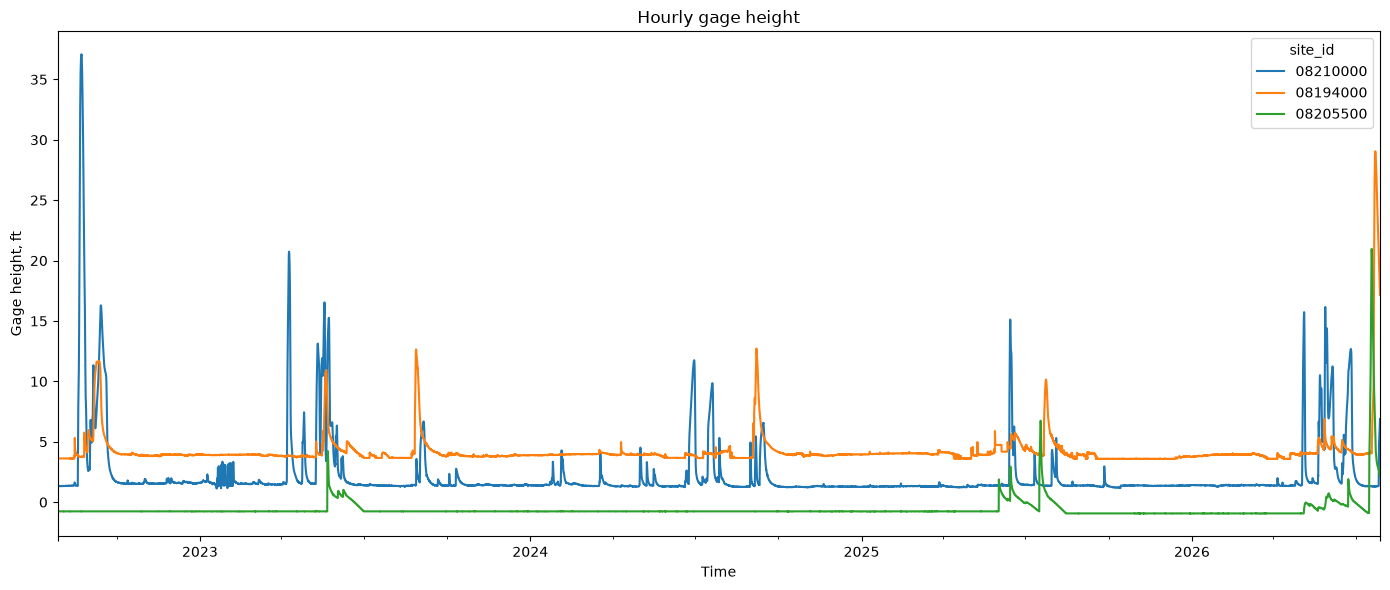

In [18]:
stage_model.plot(
    figsize=(14, 6),
    title="Hourly gage height"
)

plt.xlabel("Time")
plt.ylabel("Gage height, ft")
plt.tight_layout()
plt.show()

In [48]:
negative_rows = df.loc[
    (df["site_id"] == 8205500)
    & (pd.to_numeric(df["value"], errors="coerce") < 0),
    ["datetime", "site_id", "parameter_name", "value"]
]

print(negative_rows)

                          datetime  site_id  parameter_name  value
3467602  2010-08-30 14:30:00+00:00  8205500  gage_height_ft  -0.01
3467606  2010-08-30 15:30:00+00:00  8205500  gage_height_ft  -0.01
3467608  2010-08-30 16:00:00+00:00  8205500  gage_height_ft  -0.01
3467610  2010-08-30 16:30:00+00:00  8205500  gage_height_ft  -0.01
3467611  2010-08-30 16:45:00+00:00  8205500  gage_height_ft  -0.01
...                            ...      ...             ...    ...
4019505  2026-07-15 17:45:00+00:00  8205500  gage_height_ft  -0.90
4019506  2026-07-15 18:00:00+00:00  8205500  gage_height_ft  -0.90
4019507  2026-07-15 18:15:00+00:00  8205500  gage_height_ft  -0.90
4019508  2026-07-15 18:30:00+00:00  8205500  gage_height_ft  -0.75
4019509  2026-07-15 18:45:00+00:00  8205500  gage_height_ft  -0.02

[370218 rows x 4 columns]


In [49]:
number_of_rows = len(stage_model)

train_position = int(number_of_rows * 0.70)
validation_position = int(number_of_rows * 0.85)

train_end_time = stage_model.index[train_position]
validation_end_time = stage_model.index[validation_position]

print("Training period:")
print(stage_model.index.min(), "to", train_end_time)

print("\nValidation period:")
print(train_end_time, "to", validation_end_time)

print("\nTesting period:")
print(validation_end_time, "to", stage_model.index.max())

Training period:
2022-07-27 19:00:00+00:00 to 2025-05-15 12:00:00+00:00

Validation period:
2025-05-15 12:00:00+00:00 to 2025-12-20 16:00:00+00:00

Testing period:
2025-12-20 16:00:00+00:00 to 2026-07-27 19:00:00+00:00


In [50]:
training_rows = stage_model.index < train_end_time

training_data = stage_model.loc[
    training_rows,
    FEATURE_GAUGES
]

feature_mean = training_data.mean()
feature_std = training_data.std().replace(0, 1)

target_mean = feature_mean[TARGET_GAUGE]
target_std = feature_std[TARGET_GAUGE]

X_scaled_frame = (
    stage_model[FEATURE_GAUGES] - feature_mean
) / feature_std

y_scaled_series = (
    stage_model[TARGET_GAUGE] - target_mean
) / target_std

print("Training means:")
print(feature_mean)

print("\nTraining standard deviations:")
print(feature_std)

Training means:
site_id
08210000    2.267044
08194000    4.141496
08205500   -0.713354
dtype: float64

Training standard deviations:
site_id
08210000    3.126632
08194000    1.048330
08205500    0.279773
dtype: float64


Input X:
Previous 24 hourly observations from three gauges

Output y:
Next four hourly stages at 08210000

In [51]:
def create_hourly_sequences(
    x_frame,
    y_series,
    raw_target,
    lookback_hours=24,
    forecast_hours=4,
):
    x_values = x_frame.to_numpy(dtype=np.float32)
    y_values = y_series.to_numpy(dtype=np.float32)
    raw_target_values = raw_target.to_numpy(dtype=np.float32)

    times = x_frame.index

    X = []
    y = []

    forecast_start_times = []
    forecast_end_times = []
    last_observed_target = []

    final_forecast_start = (
        len(x_frame) - forecast_hours + 1
    )

    for forecast_start in range(
        lookback_hours,
        final_forecast_start
    ):
        x_window = x_values[
            forecast_start - lookback_hours:
            forecast_start
        ]

        y_window = y_values[
            forecast_start:
            forecast_start + forecast_hours
        ]

        # Skip windows containing unresolved missing values
        if np.isnan(x_window).any():
            continue

        if np.isnan(y_window).any():
            continue

        X.append(x_window)
        y.append(y_window)

        forecast_start_times.append(
            times[forecast_start]
        )

        forecast_end_times.append(
            times[
                forecast_start
                + forecast_hours
                - 1
            ]
        )

        last_observed_target.append(
            raw_target_values[forecast_start - 1]
        )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DatetimeIndex(forecast_start_times),
        pd.DatetimeIndex(forecast_end_times),
        np.asarray(
            last_observed_target,
            dtype=np.float32
        ),
    )

In [52]:
(
    X_all,
    y_all,
    forecast_start_times,
    forecast_end_times,
    last_observed_stage,
) = create_hourly_sequences(
    x_frame=X_scaled_frame,
    y_series=y_scaled_series,
    raw_target=stage_model[TARGET_GAUGE],
    lookback_hours=LOOKBACK_HOURS,
    forecast_hours=FORECAST_HOURS,
)

print("X shape:", X_all.shape)
print("y shape:", y_all.shape)

X shape: (34857, 24, 3)
y shape: (34857, 4)


In [53]:
train_mask = (
    forecast_end_times < train_end_time
)

validation_mask = (
    (forecast_start_times >= train_end_time)
    & (forecast_end_times < validation_end_time)
)

test_mask = (
    forecast_start_times >= validation_end_time
)

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_validation = X_all[validation_mask]
y_validation = y_all[validation_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

test_start_times = forecast_start_times[test_mask]
test_last_observed_stage = last_observed_stage[test_mask]

print("Training:")
print(X_train.shape, y_train.shape)

print("\nValidation:")
print(X_validation.shape, y_validation.shape)

print("\nTesting:")
print(X_test.shape, y_test.shape)

Training:
(24470, 24, 3) (24470, 4)

Validation:
(5233, 24, 3) (5233, 4)

Testing:
(5148, 24, 3) (5148, 4)


In [54]:
if len(X_train) == 0:
    raise ValueError("No valid training sequences were created.")

if len(X_validation) == 0:
    raise ValueError("No valid validation sequences were created.")

if len(X_test) == 0:
    raise ValueError("No valid test sequences were created.")

In [55]:
number_of_features = X_train.shape[2]

inputs = Input(
    shape=(
        LOOKBACK_HOURS,
        number_of_features,
    )
)

x = LSTM(
    units=64,
    return_sequences=False,
)(inputs)

x = Dropout(0.20)(x)

x = Dense(
    units=32,
    activation="relu",
)(x)

x = Dropout(0.10)(x)

# Four outputs:
# 1-hour, 2-hour, 3-hour, and 4-hour forecasts
outputs = Dense(
    units=FORECAST_HOURS,
    activation="linear",
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.Huber(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        )
    ],
)

model.summary()

E0000 00:00:1785261773.629409   61058 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1785261773.629444   61058 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1785261773.629447   61058 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: gpu118
I0000 00:00:1785261773.629451   61058 cuda_diagnostics.cc:183] hostname: gpu118
I0000 00:00:1785261773.629492   61058 cuda_diagnostics.cc:190] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program. The library may be missing or provided via another object.
I0000 00:00:1785261773.629510   61058 cuda_diagnostics.cc:194] kernel reported version is: 550.127.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,620 (76.64 KB)

 Trainable params: 19,620 (76.64 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1,
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [57]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_validation,
        y_validation,
    ),

    epochs=100,
    batch_size=64,

    # These are independent sequence samples,
    # so shuffling within the training set is acceptable.
    shuffle=True,

    callbacks=callbacks,
    verbose=1,
)


Epoch 1/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0293 - mae: 0.1033 - val_loss: 0.0075 - val_mae: 0.0526 - learning_rate: 0.0010
Epoch 2/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0115 - mae: 0.0640 - val_loss: 0.0106 - val_mae: 0.0561 - learning_rate: 0.0010
Epoch 3/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0101 - mae: 0.0585 - val_loss: 0.0033 - val_mae: 0.0379 - learning_rate: 0.0010
Epoch 4/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0095 - mae: 0.0544 - val_loss: 0.0059 - val_mae: 0.0399 - learning_rate: 0.0010
Epoch 5/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0086 - mae: 0.0520 - val_loss: 0.0022 - val_mae: 0.0210 - learning_rate: 0.0010
Epoch 6/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0079 - mae: 0.0497 - val_loss: 0.0016 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 7/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0075 - mae: 0.0478 - val_loss: 0.0029 - val_mae: 0.0260 - learning_rate: 0.0010

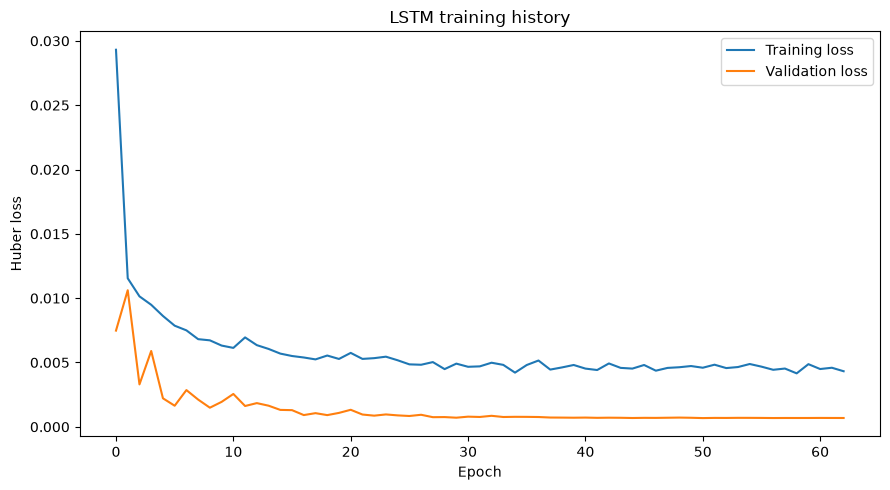

In [58]:
plt.figure(figsize=(9, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.title("LSTM training history")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
predicted_scaled = model.predict(
    X_test,
    batch_size=256,
    verbose=0,
)

In [60]:
def inverse_stage_transform(scaled_values):
    return (
        scaled_values * target_std
        + target_mean
    )


observed_stage_ft = inverse_stage_transform(
    y_test
)

predicted_stage_ft = inverse_stage_transform(
    predicted_scaled
)

print("Observed:", observed_stage_ft.shape)
print("Predicted:", predicted_stage_ft.shape)

Observed: (5148, 4)
Predicted: (5148, 4)


In [61]:
persistence_stage_ft = np.repeat(
    test_last_observed_stage[:, np.newaxis],
    FORECAST_HOURS,
    axis=1,
)

In [62]:
def mae(observed, predicted):
    observed = np.asarray(observed)
    predicted = np.asarray(predicted)

    return np.mean(
        np.abs(predicted - observed)
    )


def rmse(observed, predicted):
    observed = np.asarray(observed)
    predicted = np.asarray(predicted)

    return np.sqrt(
        np.mean((predicted - observed) ** 2)
    )


def nse(observed, predicted):
    observed = np.asarray(observed)
    predicted = np.asarray(predicted)

    denominator = np.sum(
        (observed - observed.mean()) ** 2
    )

    if denominator == 0:
        return np.nan

    return 1 - (
        np.sum((predicted - observed) ** 2)
        / denominator
    )

In [63]:
metric_rows = []

for horizon_index in range(FORECAST_HOURS):
    lead_hour = horizon_index + 1

    observed = observed_stage_ft[:, horizon_index]
    predicted = predicted_stage_ft[:, horizon_index]
    persistence = persistence_stage_ft[:, horizon_index]

    metric_rows.append({
        "lead_hour": lead_hour,

        "lstm_mae_ft": mae(
            observed,
            predicted
        ),

        "lstm_rmse_ft": rmse(
            observed,
            predicted
        ),

        "lstm_nse": nse(
            observed,
            predicted
        ),

        "persistence_mae_ft": mae(
            observed,
            persistence
        ),

        "persistence_rmse_ft": rmse(
            observed,
            persistence
        ),

        "persistence_nse": nse(
            observed,
            persistence
        ),
    })

metrics = pd.DataFrame(metric_rows)

print(metrics.round(4))

   lead_hour  lstm_mae_ft  lstm_rmse_ft  lstm_nse  persistence_mae_ft  \
0          1       0.0583        0.1344    0.9978              0.0266   
1          2       0.0601        0.1501    0.9973              0.0523   
2          3       0.0769        0.1974    0.9953              0.0777   
3          4       0.0977        0.2486    0.9926              0.1028   

   persistence_rmse_ft  persistence_nse  
0               0.0851           0.9991  
1               0.1678           0.9966  
2               0.2490           0.9926  
3               0.3288           0.9871  


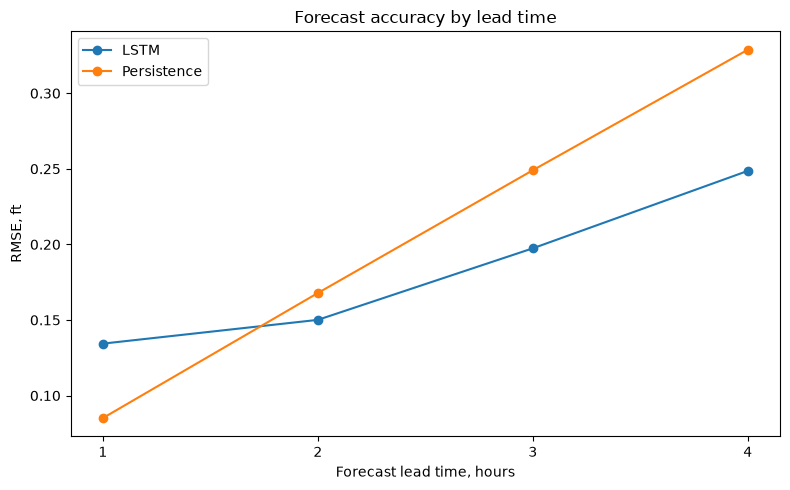

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    metrics["lead_hour"],
    metrics["lstm_rmse_ft"],
    marker="o",
    label="LSTM"
)

plt.plot(
    metrics["lead_hour"],
    metrics["persistence_rmse_ft"],
    marker="o",
    label="Persistence"
)

plt.xlabel("Forecast lead time, hours")
plt.ylabel("RMSE, ft")
plt.title("Forecast accuracy by lead time")
plt.xticks([1, 2, 3, 4])
plt.legend()
plt.tight_layout()
plt.show()

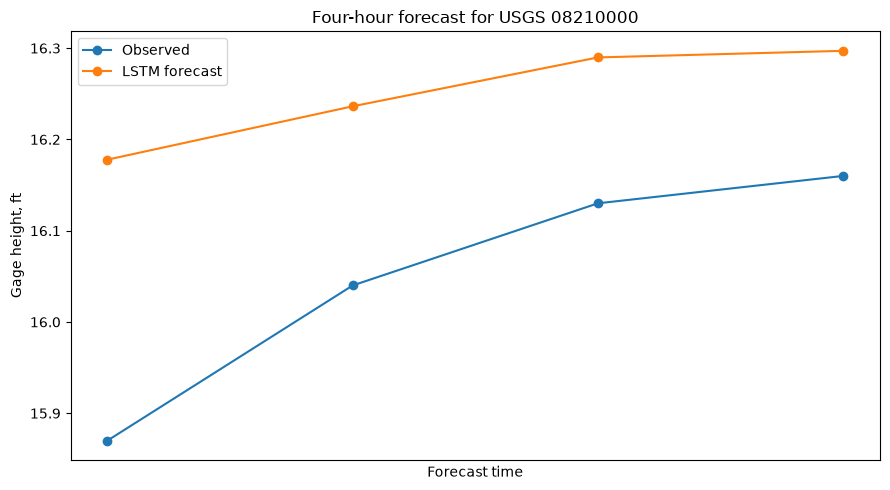

In [72]:
sample_index = np.argmax(
    observed_stage_ft.max(axis=1)
)

sample_times = pd.date_range(
    start=test_start_times[sample_index],
    periods=FORECAST_HOURS,
    freq="1h",
)

plt.figure(figsize=(9, 5))

plt.plot(
    sample_times,
    observed_stage_ft[sample_index],
    marker="o",
    label="Observed"
)

plt.plot(
    sample_times,
    predicted_stage_ft[sample_index],
    marker="o",
    label="LSTM forecast"
)


plt.xlabel("Forecast time")
plt.ylabel("Gage height, ft")
plt.title(
    f"Four-hour forecast for USGS {TARGET_GAUGE}"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
threshold_columns = [
    "action_stage_ft",
    "minor_flood_stage_ft",
    "moderate_flood_stage_ft",
    "major_flood_stage_ft",
]

target_metadata = data.loc[
    data["site_id"] == TARGET_GAUGE,
    threshold_columns
].copy()

thresholds = {}

for column in threshold_columns:
    available_values = (
        pd.to_numeric(
            target_metadata[column],
            errors="coerce"
        )
        .dropna()
    )

    if len(available_values) > 0:
        thresholds[column] = float(
            available_values.iloc[-1]
        )
    else:
        thresholds[column] = np.nan

print(thresholds)

{'action_stage_ft': 20.0, 'minor_flood_stage_ft': 25.0, 'moderate_flood_stage_ft': 27.0, 'major_flood_stage_ft': 35.0}


In [68]:
def classify_stage(stage_ft, threshold_dictionary):
    action = threshold_dictionary[
        "action_stage_ft"
    ]

    minor = threshold_dictionary[
        "minor_flood_stage_ft"
    ]

    moderate = threshold_dictionary[
        "moderate_flood_stage_ft"
    ]

    major = threshold_dictionary[
        "major_flood_stage_ft"
    ]

    if pd.notna(major) and stage_ft >= major:
        return "Major Flood"

    if pd.notna(moderate) and stage_ft >= moderate:
        return "Moderate Flood"

    if pd.notna(minor) and stage_ft >= minor:
        return "Minor Flood"

    if pd.notna(action) and stage_ft >= action:
        return "Action Stage"

    return "Below Action Stage"

In [69]:
warning_forecast = pd.DataFrame({
    "datetime": sample_times,
    "observed_stage_ft":
        observed_stage_ft[sample_index],
    "predicted_stage_ft":
        predicted_stage_ft[sample_index],
})

warning_forecast["predicted_warning"] = (
    warning_forecast[
        "predicted_stage_ft"
    ].apply(
        lambda value: classify_stage(
            value,
            thresholds
        )
    )
)

print(warning_forecast)

                   datetime  observed_stage_ft  predicted_stage_ft  \
0 2026-05-28 04:00:00+00:00          15.869999           16.177833   
1 2026-05-28 05:00:00+00:00          16.040000           16.236279   
2 2026-05-28 06:00:00+00:00          16.129999           16.289828   
3 2026-05-28 07:00:00+00:00          16.160001           16.297061   

    predicted_warning  
0  Below Action Stage  
1  Below Action Stage  
2  Below Action Stage  
3  Below Action Stage  


In [71]:
latest_window = (
    X_scaled_frame[FEATURE_GAUGES]
    .iloc[-LOOKBACK_HOURS:]
    .to_numpy(dtype=np.float32)
)

if len(latest_window) != LOOKBACK_HOURS:
    raise ValueError(
        "There are not enough recent hourly observations."
    )

if np.isnan(latest_window).any():
    raise ValueError(
        "The latest 24-hour input window contains missing values."
    )

latest_window = latest_window[
    np.newaxis,
    :,
    :
]

latest_prediction_scaled = model.predict(
    latest_window,
    verbose=0,
)

latest_prediction_ft = inverse_stage_transform(
    latest_prediction_scaled
)[0]

latest_observation_time = stage_model.index[-1]

future_times = pd.date_range(
    start=latest_observation_time
    + pd.Timedelta(hours=1),
    periods=FORECAST_HOURS,
    freq="1h",
)

latest_forecast = pd.DataFrame({
    "datetime": future_times,
    "predicted_stage_ft": latest_prediction_ft,
})

latest_forecast["warning_level"] = (
    latest_forecast[
        "predicted_stage_ft"
    ].apply(
        lambda value: classify_stage(
            value,
            thresholds
        )
    )
)

print(latest_forecast)

                   datetime  predicted_stage_ft       warning_level
0 2026-07-27 20:00:00+00:00            6.866194  Below Action Stage
1 2026-07-27 21:00:00+00:00            6.868530  Below Action Stage
2 2026-07-27 22:00:00+00:00            6.908099  Below Action Stage
3 2026-07-27 23:00:00+00:00            6.890666  Below Action Stage


# Save the model

In [73]:
model.save(
    "gage_height_lstm_08210000.keras"
)

In [74]:
scaling_parameters = pd.DataFrame({
    "mean": feature_mean,
    "std": feature_std,
})

scaling_parameters.to_csv(
    "gage_height_scaling_parameters.csv"
)